In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [4]:
sales = pd.read_csv("../data/processed/sales_clean.csv")

In [5]:
daily_sales = sales.groupby("Date")["Revenue"].sum()

daily_sales.head()

Date
2024-01-01    4063745.96
2024-01-02    3801096.22
2024-01-03    3916930.74
2024-01-04    3998566.70
2024-01-05    3754297.61
Name: Revenue, dtype: float64

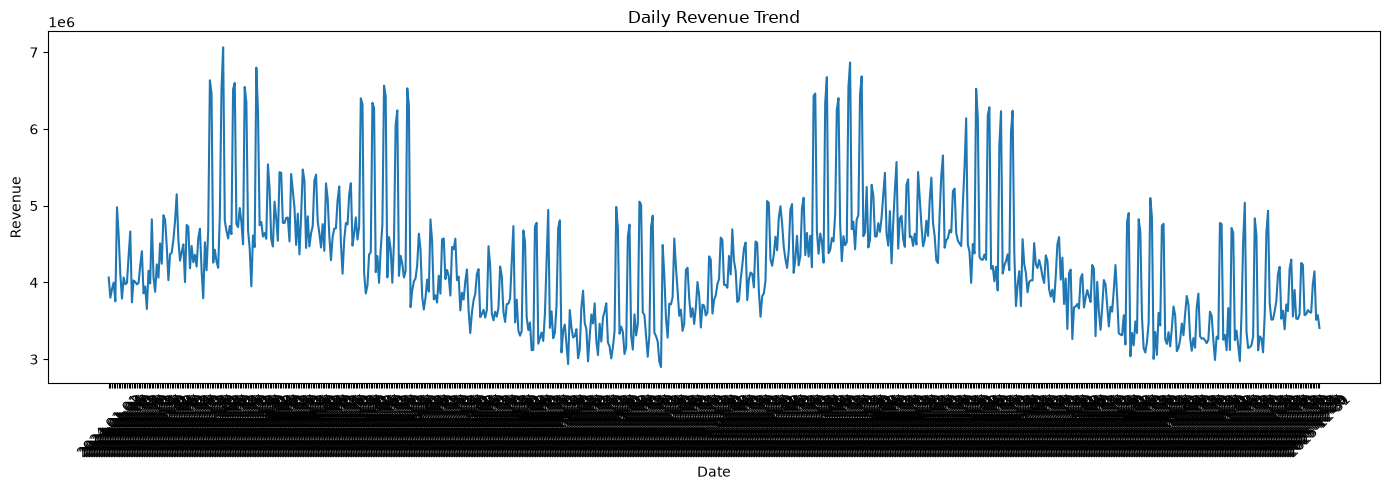

In [6]:
plt.figure(figsize=(14, 5))

plt.plot(daily_sales.index, daily_sales.values)

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/jr/4njd4_1j07l5kswk4b8pc5p40000gn/T/ipykernel_61520/953694423.py:10: UserWarning: 'set_params()' not defined for locator of type <class 'matplotlib.category.StrCategoryLocator'>
  plt.locator_params(axis="x", nbins=12)


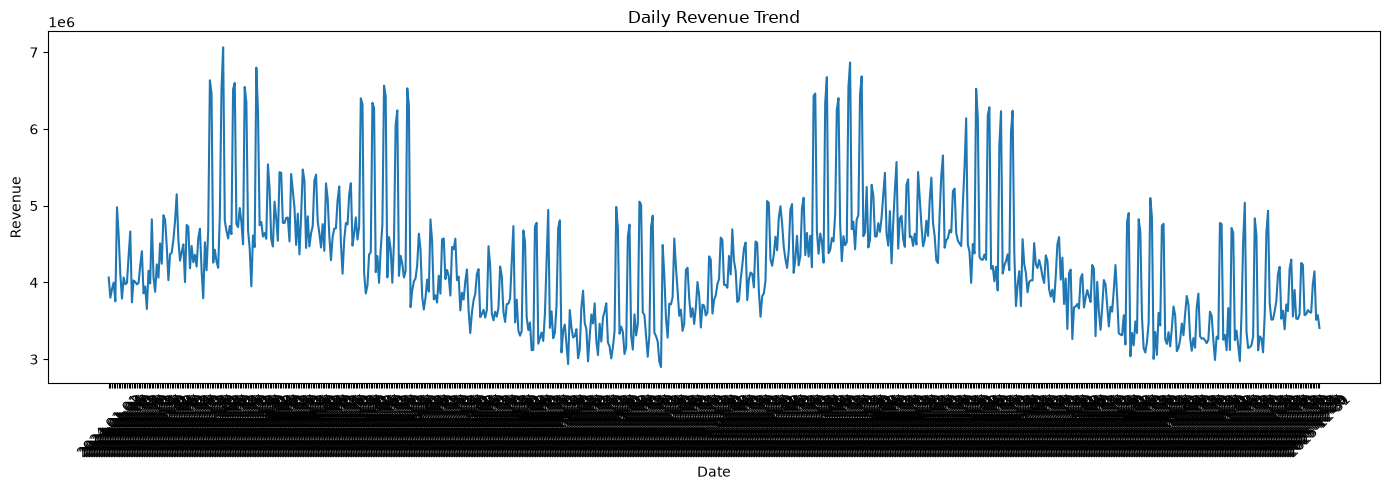

In [7]:
plt.figure(figsize=(14, 5))

plt.plot(daily_sales.index, daily_sales.values)

plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.locator_params(axis="x", nbins=12)

plt.tight_layout()
plt.show()

In [8]:
sku_revenue = (
    sales.groupby("SKU")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

sku_revenue.head(10)

SKU
SKU026    1.808853e+08
SKU035    1.691619e+08
SKU012    1.673962e+08
SKU042    1.528478e+08
SKU027    1.508886e+08
SKU045    1.428802e+08
SKU043    1.423462e+08
SKU029    1.342374e+08
SKU031    1.195913e+08
SKU008    1.175605e+08
Name: Revenue, dtype: float64

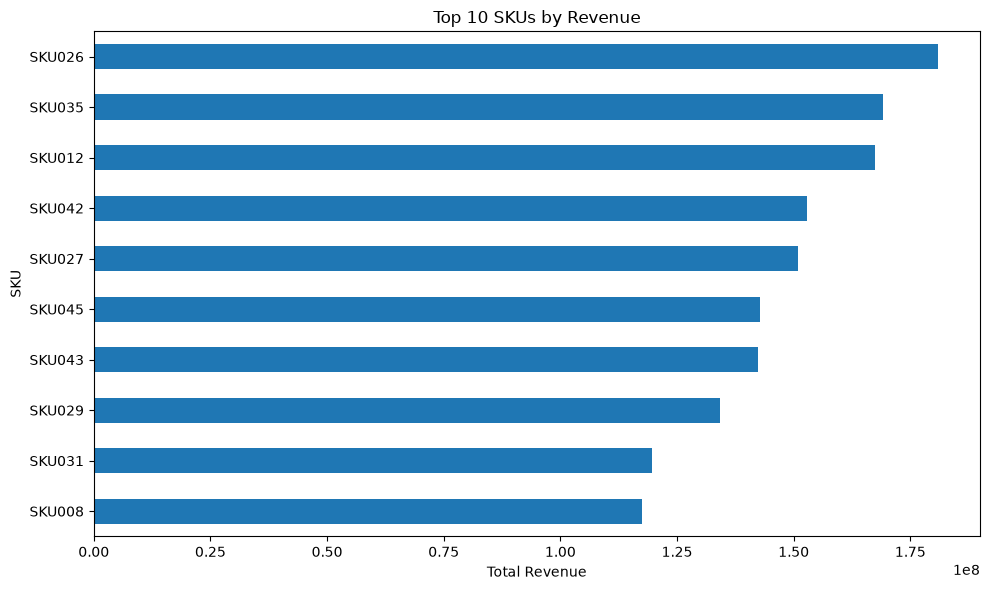

In [9]:
plt.figure(figsize=(10, 6))

sku_revenue.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 SKUs by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("SKU")

plt.tight_layout()
plt.show()

In [10]:
sku_units = (
    sales.groupby("SKU")["Units_Sold"]
    .sum()
    .sort_values(ascending=False)
)

sku_units.head(10)


SKU
SKU012    19067
SKU045    18612
SKU018    18450
SKU049    18373
SKU037    18155
SKU007    18129
SKU027    17717
SKU042    16616
SKU026    16535
SKU043    16276
Name: Units_Sold, dtype: int64

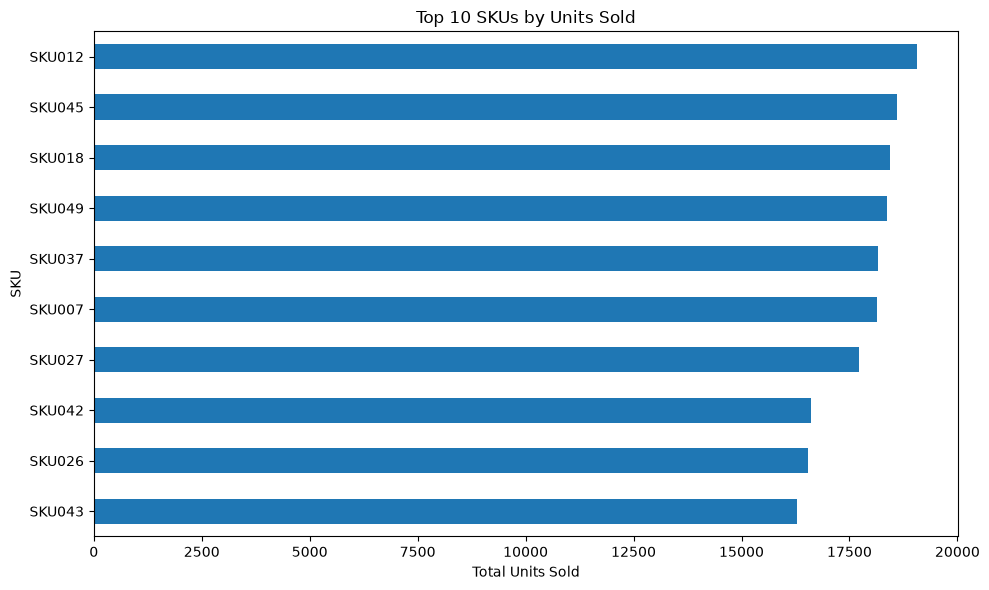

In [11]:
plt.figure(figsize=(10, 6))

sku_units.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 SKUs by Units Sold")
plt.xlabel("Total Units Sold")
plt.ylabel("SKU")

plt.tight_layout()
plt.show()

In [12]:
sku_summary = (
    sales.groupby("SKU")
    .agg(
        Total_Units=("Units_Sold", "sum"),
        Total_Revenue=("Revenue", "sum"),
        Average_Price=("Price", "mean")
    )
    .sort_values("Total_Revenue", ascending=False)
)

sku_summary.head(10)

,Total_Units,Total_Revenue,Average_Price
SKU,,,
SKU026,16535,1.808853e+08,10939.54
SKU035,15562,1.691619e+08,10870.19
SKU012,19067,1.673962e+08,8779.37
SKU042,16616,1.528478e+08,9198.83
SKU027,17717,1.508886e+08,8516.60
SKU045,18612,1.428802e+08,7676.78
SKU043,16276,1.423462e+08,8745.77
SKU029,11530,1.342374e+08,11642.45
SKU031,13721,1.195913e+08,8715.93


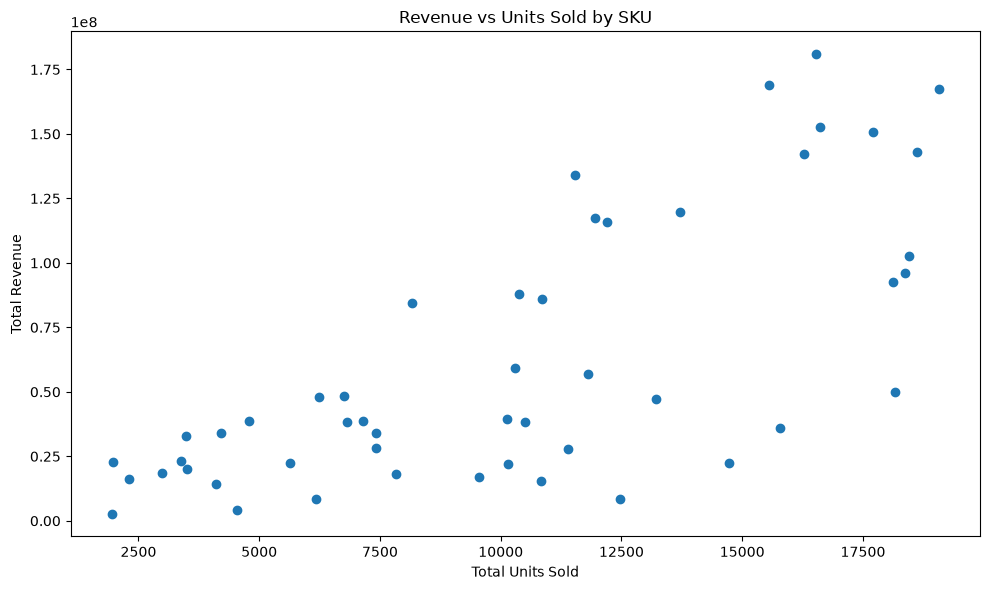

In [13]:
plt.figure(figsize=(10, 6))

plt.scatter(
    sku_summary["Total_Units"],
    sku_summary["Total_Revenue"]
)

plt.xlabel("Total Units Sold")
plt.ylabel("Total Revenue")
plt.title("Revenue vs Units Sold by SKU")

plt.tight_layout()
plt.show()

In [14]:
promotion_sales = (
    sales.groupby("Promotion")
    .agg(
        Average_Units_Sold=("Units_Sold", "mean"),
        Total_Units_Sold=("Units_Sold", "sum"),
        Average_Revenue=("Revenue", "mean"),
        Total_Revenue=("Revenue", "sum")
    )
)

promotion_sales

,Average_Units_Sold,Total_Units_Sold,Average_Revenue,Total_Revenue
Promotion,,,,
0,13.475945,442011,81550.078302,2.674843e+09
1,18.613067,69799,112323.770379,4.212141e+08


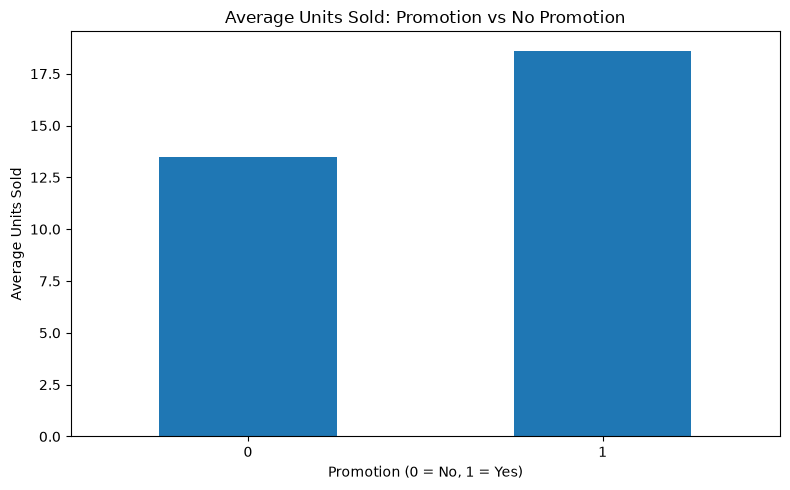

In [15]:
plt.figure(figsize=(8, 5))

promotion_sales["Average_Units_Sold"].plot(kind="bar")

plt.title("Average Units Sold: Promotion vs No Promotion")
plt.xlabel("Promotion (0 = No, 1 = Yes)")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [16]:
daily_units = (
    sales.groupby("Date")["Units_Sold"]
    .sum()
)

daily_units.head()

Date
2024-01-01    667
2024-01-02    643
2024-01-03    641
2024-01-04    658
2024-01-05    619
Name: Units_Sold, dtype: int64

/var/folders/jr/4njd4_1j07l5kswk4b8pc5p40000gn/T/ipykernel_61520/2259915437.py:10: UserWarning: 'set_params()' not defined for locator of type <class 'matplotlib.category.StrCategoryLocator'>
  plt.locator_params(axis="x", nbins=12)


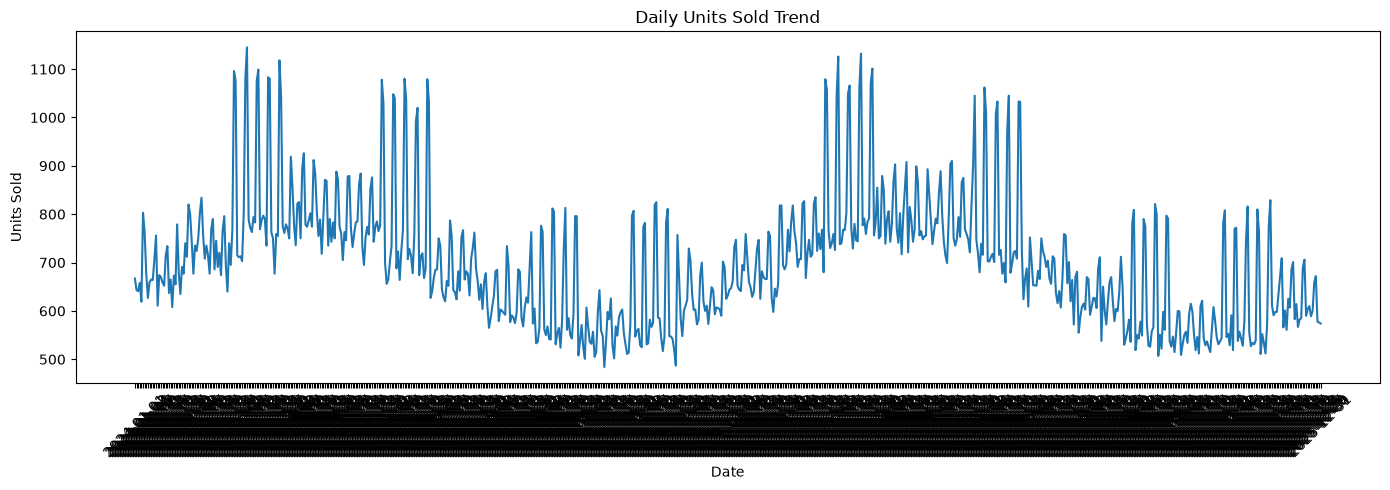

In [17]:
plt.figure(figsize=(14, 5))

plt.plot(daily_units.index, daily_units.values)

plt.title("Daily Units Sold Trend")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.xticks(rotation=45)
plt.locator_params(axis="x", nbins=12)

plt.tight_layout()
plt.show()

In [18]:
monthly_units = (
    sales.set_index("Date")
    .resample("ME")["Units_Sold"]
    .sum()
)

monthly_units

TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'Index'

In [19]:
sales["Date"] = pd.to_datetime(sales["Date"])

sales.dtypes

Date          datetime64[us]
SKU                      str
Units_Sold             int64
Revenue              float64
Price                float64
Promotion              int64
dtype: object

In [20]:
monthly_units = (
    sales.set_index("Date")
    .resample("ME")["Units_Sold"]
    .sum()
)

monthly_units

Date
2024-01-31    20961
2024-02-29    21333
2024-03-31    26791
2024-04-30    24177
2024-05-31    24402
2024-06-30    24506
2024-07-31    21118
2024-08-31    19351
2024-09-30    18723
2024-10-31    17173
2024-11-30    18660
2024-12-31    19390
2025-01-31    20938
2025-02-28    20944
2025-03-31    26757
2025-04-30    23959
2025-05-31    24636
2025-06-30    24110
2025-07-31    20998
2025-08-31    19403
2025-09-30    18408
2025-10-31    17217
2025-11-30    18717
2025-12-31    19138
Freq: ME, Name: Units_Sold, dtype: int64

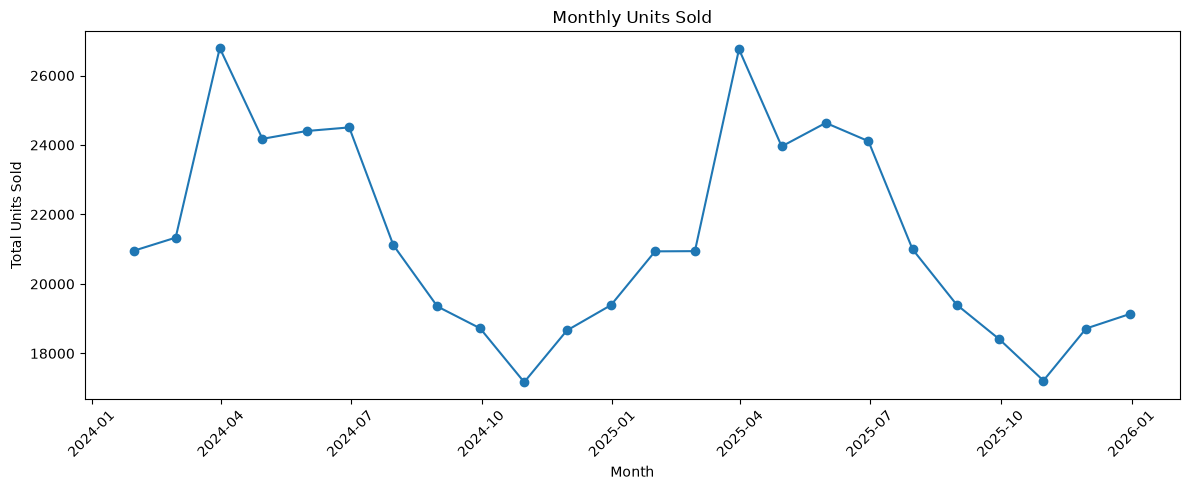

In [21]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_units.index, monthly_units.values, marker="o")

plt.title("Monthly Units Sold")
plt.xlabel("Month")
plt.ylabel("Total Units Sold")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [22]:
monthly_pattern = (
    sales.assign(Month=sales["Date"].dt.month)
    .groupby("Month")["Units_Sold"]
    .mean()
)

monthly_pattern

Month
1     13.515806
2     14.834035
3     17.273548
4     16.045333
5     15.818710
6     16.205333
7     13.585806
8     12.501290
9     12.377000
10    11.093548
11    12.459000
12    12.428387
Name: Units_Sold, dtype: float64

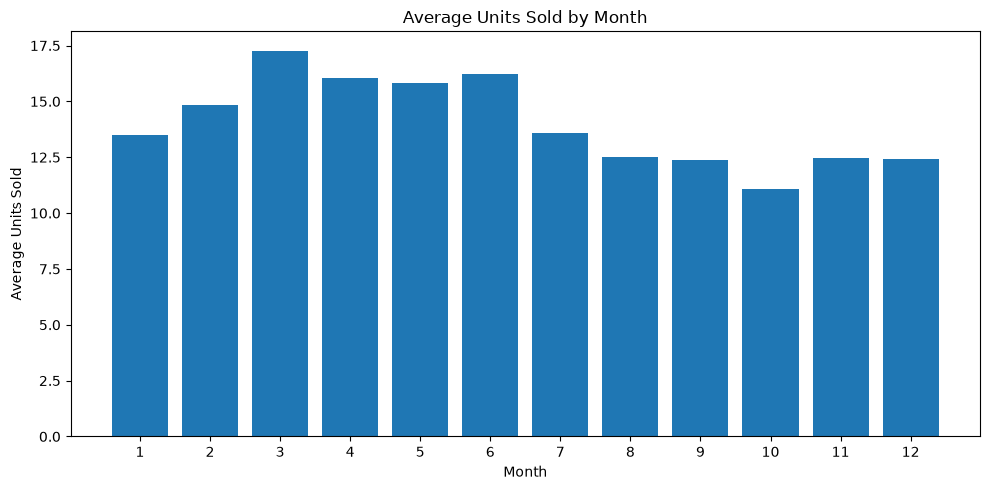

In [23]:
plt.figure(figsize=(10, 5))

plt.bar(monthly_pattern.index, monthly_pattern.values)

plt.title("Average Units Sold by Month")
plt.xlabel("Month")
plt.ylabel("Average Units Sold")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [24]:
promotion_by_sku = (
    sales.groupby(["SKU", "Promotion"])["Units_Sold"]
    .mean()
    .unstack()
)

promotion_by_sku.columns = ["No_Promotion", "Promotion"]

promotion_by_sku["Promotion_Impact"] = (
    promotion_by_sku["Promotion"] -
    promotion_by_sku["No_Promotion"]
)

promotion_by_sku.sort_values(
    "Promotion_Impact",
    ascending=False
).head(10)

,No_Promotion,Promotion,Promotion_Impact
SKU,,,
SKU012,24.923780,36.226667,11.302886
SKU045,24.442073,34.373333,9.931260
SKU007,23.823171,33.346667,9.523496
SKU034,19.236280,28.160000,8.923720
SKU027,23.352134,31.973333,8.621199
SKU014,20.730183,29.133333,8.403150
SKU037,23.996951,32.173333,8.176382
SKU018,24.402439,32.560000,8.157561
SKU043,21.437500,29.506667,8.069167


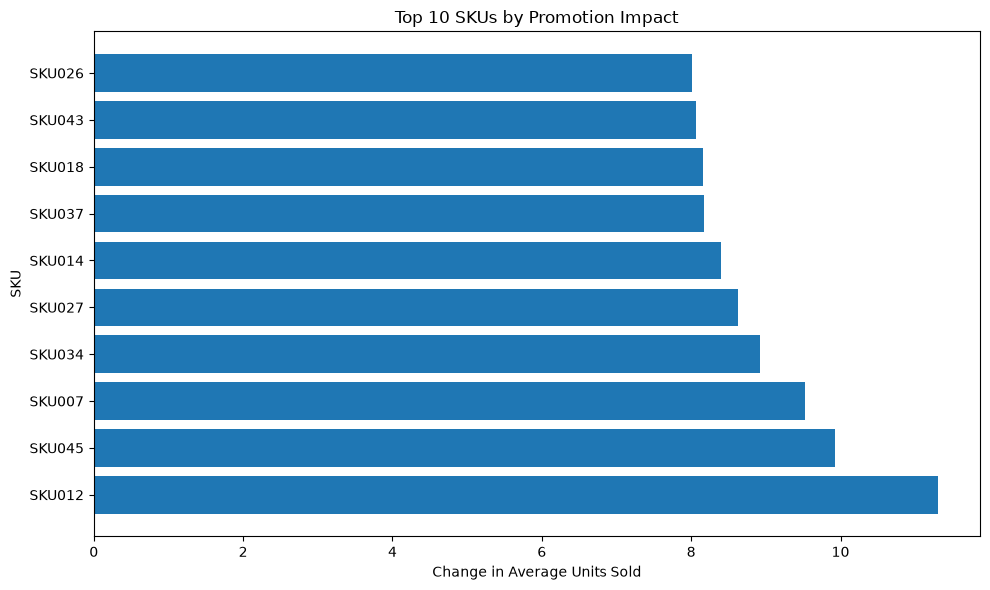

In [25]:
top_promo = promotion_by_sku.sort_values(
    "Promotion_Impact",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_promo.index,
    top_promo["Promotion_Impact"]
)

plt.title("Top 10 SKUs by Promotion Impact")
plt.xlabel("Change in Average Units Sold")
plt.ylabel("SKU")

plt.tight_layout()
plt.show()

In [26]:
correlation = sales[
    ["Units_Sold", "Revenue", "Price", "Promotion"]
].corr()

correlation

,Units_Sold,Revenue,Price,Promotion
Units_Sold,1.000000,0.748263,8.249497e-02,1.840966e-01
Revenue,0.748263,1.000000,6.340407e-01,1.220092e-01
Price,0.082495,0.634041,1.000000e+00,2.066683e-16
Promotion,0.184097,0.122009,2.066683e-16,1.000000e+00


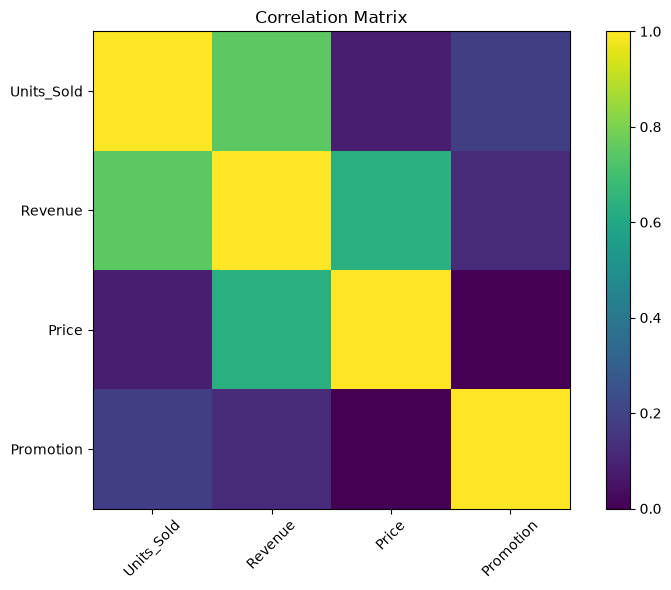

In [27]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation, interpolation="nearest")
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [28]:
sales["Year"] = sales["Date"].dt.year
sales["Month"] = sales["Date"].dt.month
sales["Day"] = sales["Date"].dt.day
sales["DayOfWeek"] = sales["Date"].dt.dayofweek
sales["Quarter"] = sales["Date"].dt.quarter

sales.head()

,Date,SKU,Units_Sold,Revenue,Price,Promotion,Year,Month,Day,DayOfWeek,Quarter
0,2024-01-01,SKU001,5,18320.25,3664.05,0,2024,1,1,0,1
1,2024-01-01,SKU002,15,57085.35,3805.69,0,2024,1,1,0,1
2,2024-01-01,SKU003,5,40391.15,8078.23,0,2024,1,1,0,1
3,2024-01-01,SKU004,5,34307.85,6861.57,0,2024,1,1,0,1
4,2024-01-01,SKU005,12,113918.64,9493.22,0,2024,1,1,0,1


In [29]:
sales[[
    "Date",
    "Year",
    "Month",
    "DayOfWeek",
    "Quarter",
    "Units_Sold"
]].head(10)

,Date,Year,Month,DayOfWeek,Quarter,Units_Sold
0,2024-01-01,2024,1,0,1,5
1,2024-01-01,2024,1,0,1,15
2,2024-01-01,2024,1,0,1,5
3,2024-01-01,2024,1,0,1,5
4,2024-01-01,2024,1,0,1,12
5,2024-01-01,2024,1,0,1,7
6,2024-01-01,2024,1,0,1,27
7,2024-01-01,2024,1,0,1,14
8,2024-01-01,2024,1,0,1,9
9,2024-01-01,2024,1,0,1,20


In [30]:
sales.to_csv(
    "../data/processed/sales_features.csv",
    index=False
)